In [1]:
!pip -q install flaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 7.7 MB/s eta 0:00:00ta 0:00:01


Установлен пакет `flaml`, который будет использоваться для автоматического подбора модели бинарной классификации.

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from flaml import AutoML

sns.set_style("whitegrid")
np.random.seed(42)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/21 09:39:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Подключены основные библиотеки для загрузки и обработки данных, визуализации, уменьшения размерности, оценки качества классификации и применения AutoML.

In [6]:
import os

csv_candidates = []

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_candidates.append(os.path.join(root, f))

print("CSV files found:")
for p in csv_candidates:
    print(p)
csv_path = csv_candidates[0]
print("CSV path:", csv_path)

CSV files found:
/kaggle/input/datasets/abokarim/module-3-dataset-practice/3 -  - .csv
CSV path: /kaggle/input/datasets/abokarim/module-3-dataset-practice/3 -  - .csv


На этом этапе выполняется автоматический поиск загруженного CSV-файла внутри директории `/kaggle/input`. Это позволяет не указывать путь вручную.

In [7]:
required_cols = [
    "Count_subj",
    "rr_interval",
    "p_end",
    "qrs_onset",
    "qrs_end",
    "p_axis",
    "qrs_axis",
    "t_axis",
    "Healthy_Status"
]

df = pd.read_csv(csv_path, usecols=required_cols, nrows=5000)

print("Shape:", df.shape)
df.head()

Shape: (5000, 9)


,Count_subj,Healthy_Status,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis
0,27,0,659,128,170,258,81,77,79
1,93,0,722,124,162,246,77,75,70
2,3,1,600,130,162,244,79,72,77
3,7,1,659,146,180,254,79,66,69
4,2,0,659,29999,504,590,84,80,77


Из исходного файла загружены только первые 5000 строк и только те столбцы, которые требуются по условию лабораторной работы. Таким образом формируется рабочая выборка для дальнейшего анализа.

In [9]:
print(df.info())
print("\nMissing values:")
print(df.isna().sum())

print("\nUnique values in Healthy_Status before processing:")
print(df["Healthy_Status"].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Count_subj      5000 non-null   int64
 1   Healthy_Status  5000 non-null   int64
 2   rr_interval     5000 non-null   int64
 3   p_end           5000 non-null   int64
 4   qrs_onset       5000 non-null   int64
 5   qrs_end         5000 non-null   int64
 6   p_axis          5000 non-null   int64
 7   qrs_axis        5000 non-null   int64
 8   t_axis          5000 non-null   int64
dtypes: int64(9)
memory usage: 351.7 KB
None

Missing values:
Count_subj        0
Healthy_Status    0
rr_interval       0
p_end             0
qrs_onset         0
qrs_end           0
p_axis            0
qrs_axis          0
t_axis            0
dtype: int64

Unique values in Healthy_Status before processing:
Healthy_Status
0    4040
1     960
Name: count, dtype: int64


Проверяется структура датасета, типы данных, наличие пропусков и распределение значений целевого признака `Healthy_Status`. Этот шаг необходим для корректной предварительной обработки.

In [10]:
df = df.dropna().copy()

if not pd.api.types.is_numeric_dtype(df["Healthy_Status"]):
    df["Healthy_Status"] = df["Healthy_Status"].astype(str).str.strip().str.lower()
    unique_targets = sorted(df["Healthy_Status"].unique())
    target_map = {unique_targets[0]: 0, unique_targets[1]: 1}
    df["Healthy_Status"] = df["Healthy_Status"].map(target_map)
    print("Target mapping:", target_map)
else:
    df["Healthy_Status"] = df["Healthy_Status"].astype(int)

print("\nTarget after processing:")
print(df["Healthy_Status"].value_counts())
df.head()


Target after processing:
Healthy_Status
0    4040
1     960
Name: count, dtype: int64


,Count_subj,Healthy_Status,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis
0,27,0,659,128,170,258,81,77,79
1,93,0,722,124,162,246,77,75,70
2,3,1,600,130,162,244,79,72,77
3,7,1,659,146,180,254,79,66,69
4,2,0,659,29999,504,590,84,80,77


На данном этапе удаляются пропущенные значения и при необходимости выполняется преобразование целевого признака `Healthy_Status` в бинарный числовой формат 0/1, необходимый для обучения классификатора.

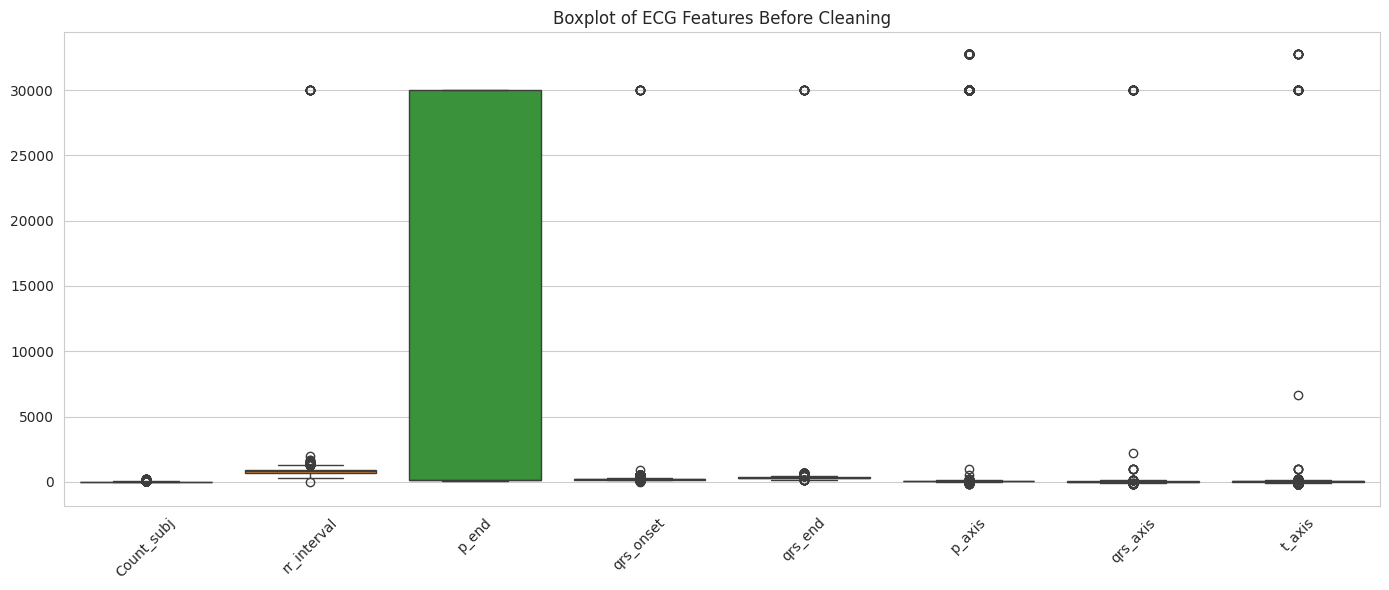

In [11]:
feature_cols = [
    "Count_subj",
    "rr_interval",
    "p_end",
    "qrs_onset",
    "qrs_end",
    "p_axis",
    "qrs_axis",
    "t_axis"
]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[feature_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of ECG Features Before Cleaning")
plt.tight_layout()
plt.savefig("/kaggle/working/boxplot_before_cleaning.png", dpi=300)
plt.show()

Построена диаграмма размаха для всех числовых признаков до очистки данных. Это позволяет визуально выявить выбросы и оценить разброс значений.

In [12]:
clean_df = df.copy()

Q1 = clean_df[feature_cols].quantile(0.25)
Q3 = clean_df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ~((clean_df[feature_cols] < lower_bound) | (clean_df[feature_cols] > upper_bound)).any(axis=1)
clean_df = clean_df[mask].copy()

print("Original shape:", df.shape)
print("Cleaned shape :", clean_df.shape)
print("\nClass distribution after cleaning:")
print(clean_df["Healthy_Status"].value_counts())

Original shape: (5000, 9)
Cleaned shape : (2941, 9)

Class distribution after cleaning:
Healthy_Status
0    2071
1     870
Name: count, dtype: int64


Для удаления выбросов применяется IQR-метод. После очистки формируется новая выборка `clean_df`, которая используется во всех последующих этапах анализа и классификации.

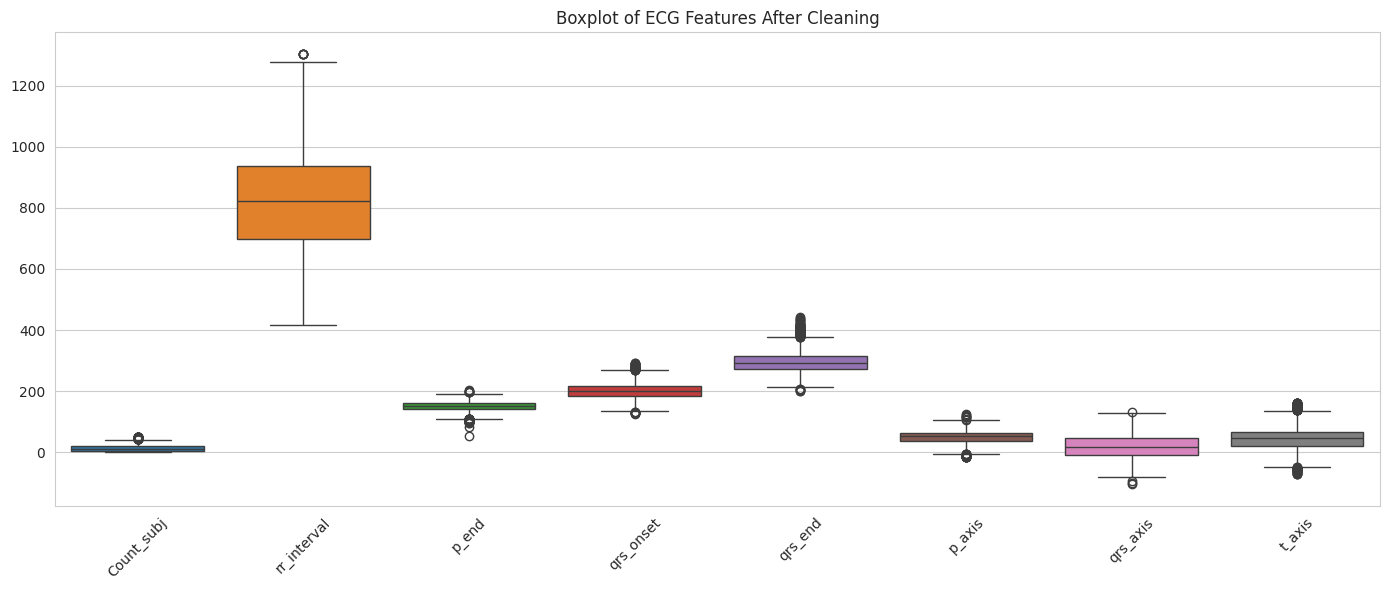

In [13]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=clean_df[feature_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of ECG Features After Cleaning")
plt.tight_layout()
plt.savefig("/kaggle/working/boxplot_after_cleaning.png", dpi=300)
plt.show()

Повторная диаграмма размаха строится уже после удаления выбросов. Это позволяет убедиться, что данные стали более устойчивыми и пригодными для последующего моделирования.

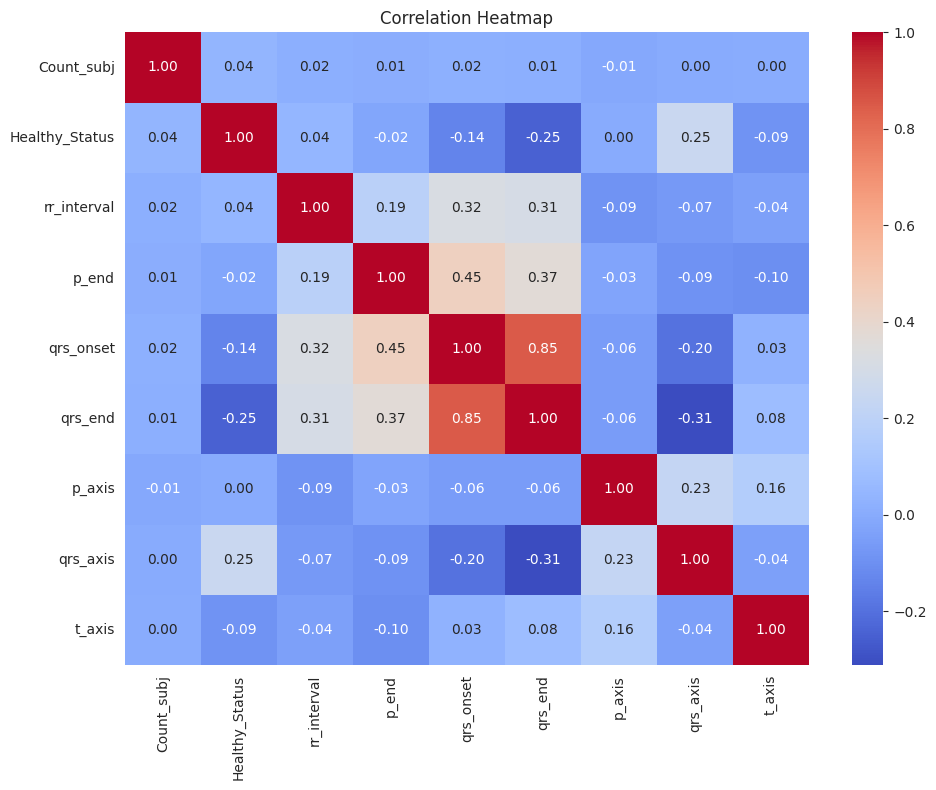

In [14]:
plt.figure(figsize=(10, 8))
corr = clean_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("/kaggle/working/correlation_heatmap.png", dpi=300)
plt.show()

Корреляционная матрица используется для анализа линейных связей между ЭКГ-признаками и целевым признаком. Тепловая карта позволяет визуально оценить степень зависимости между параметрами.

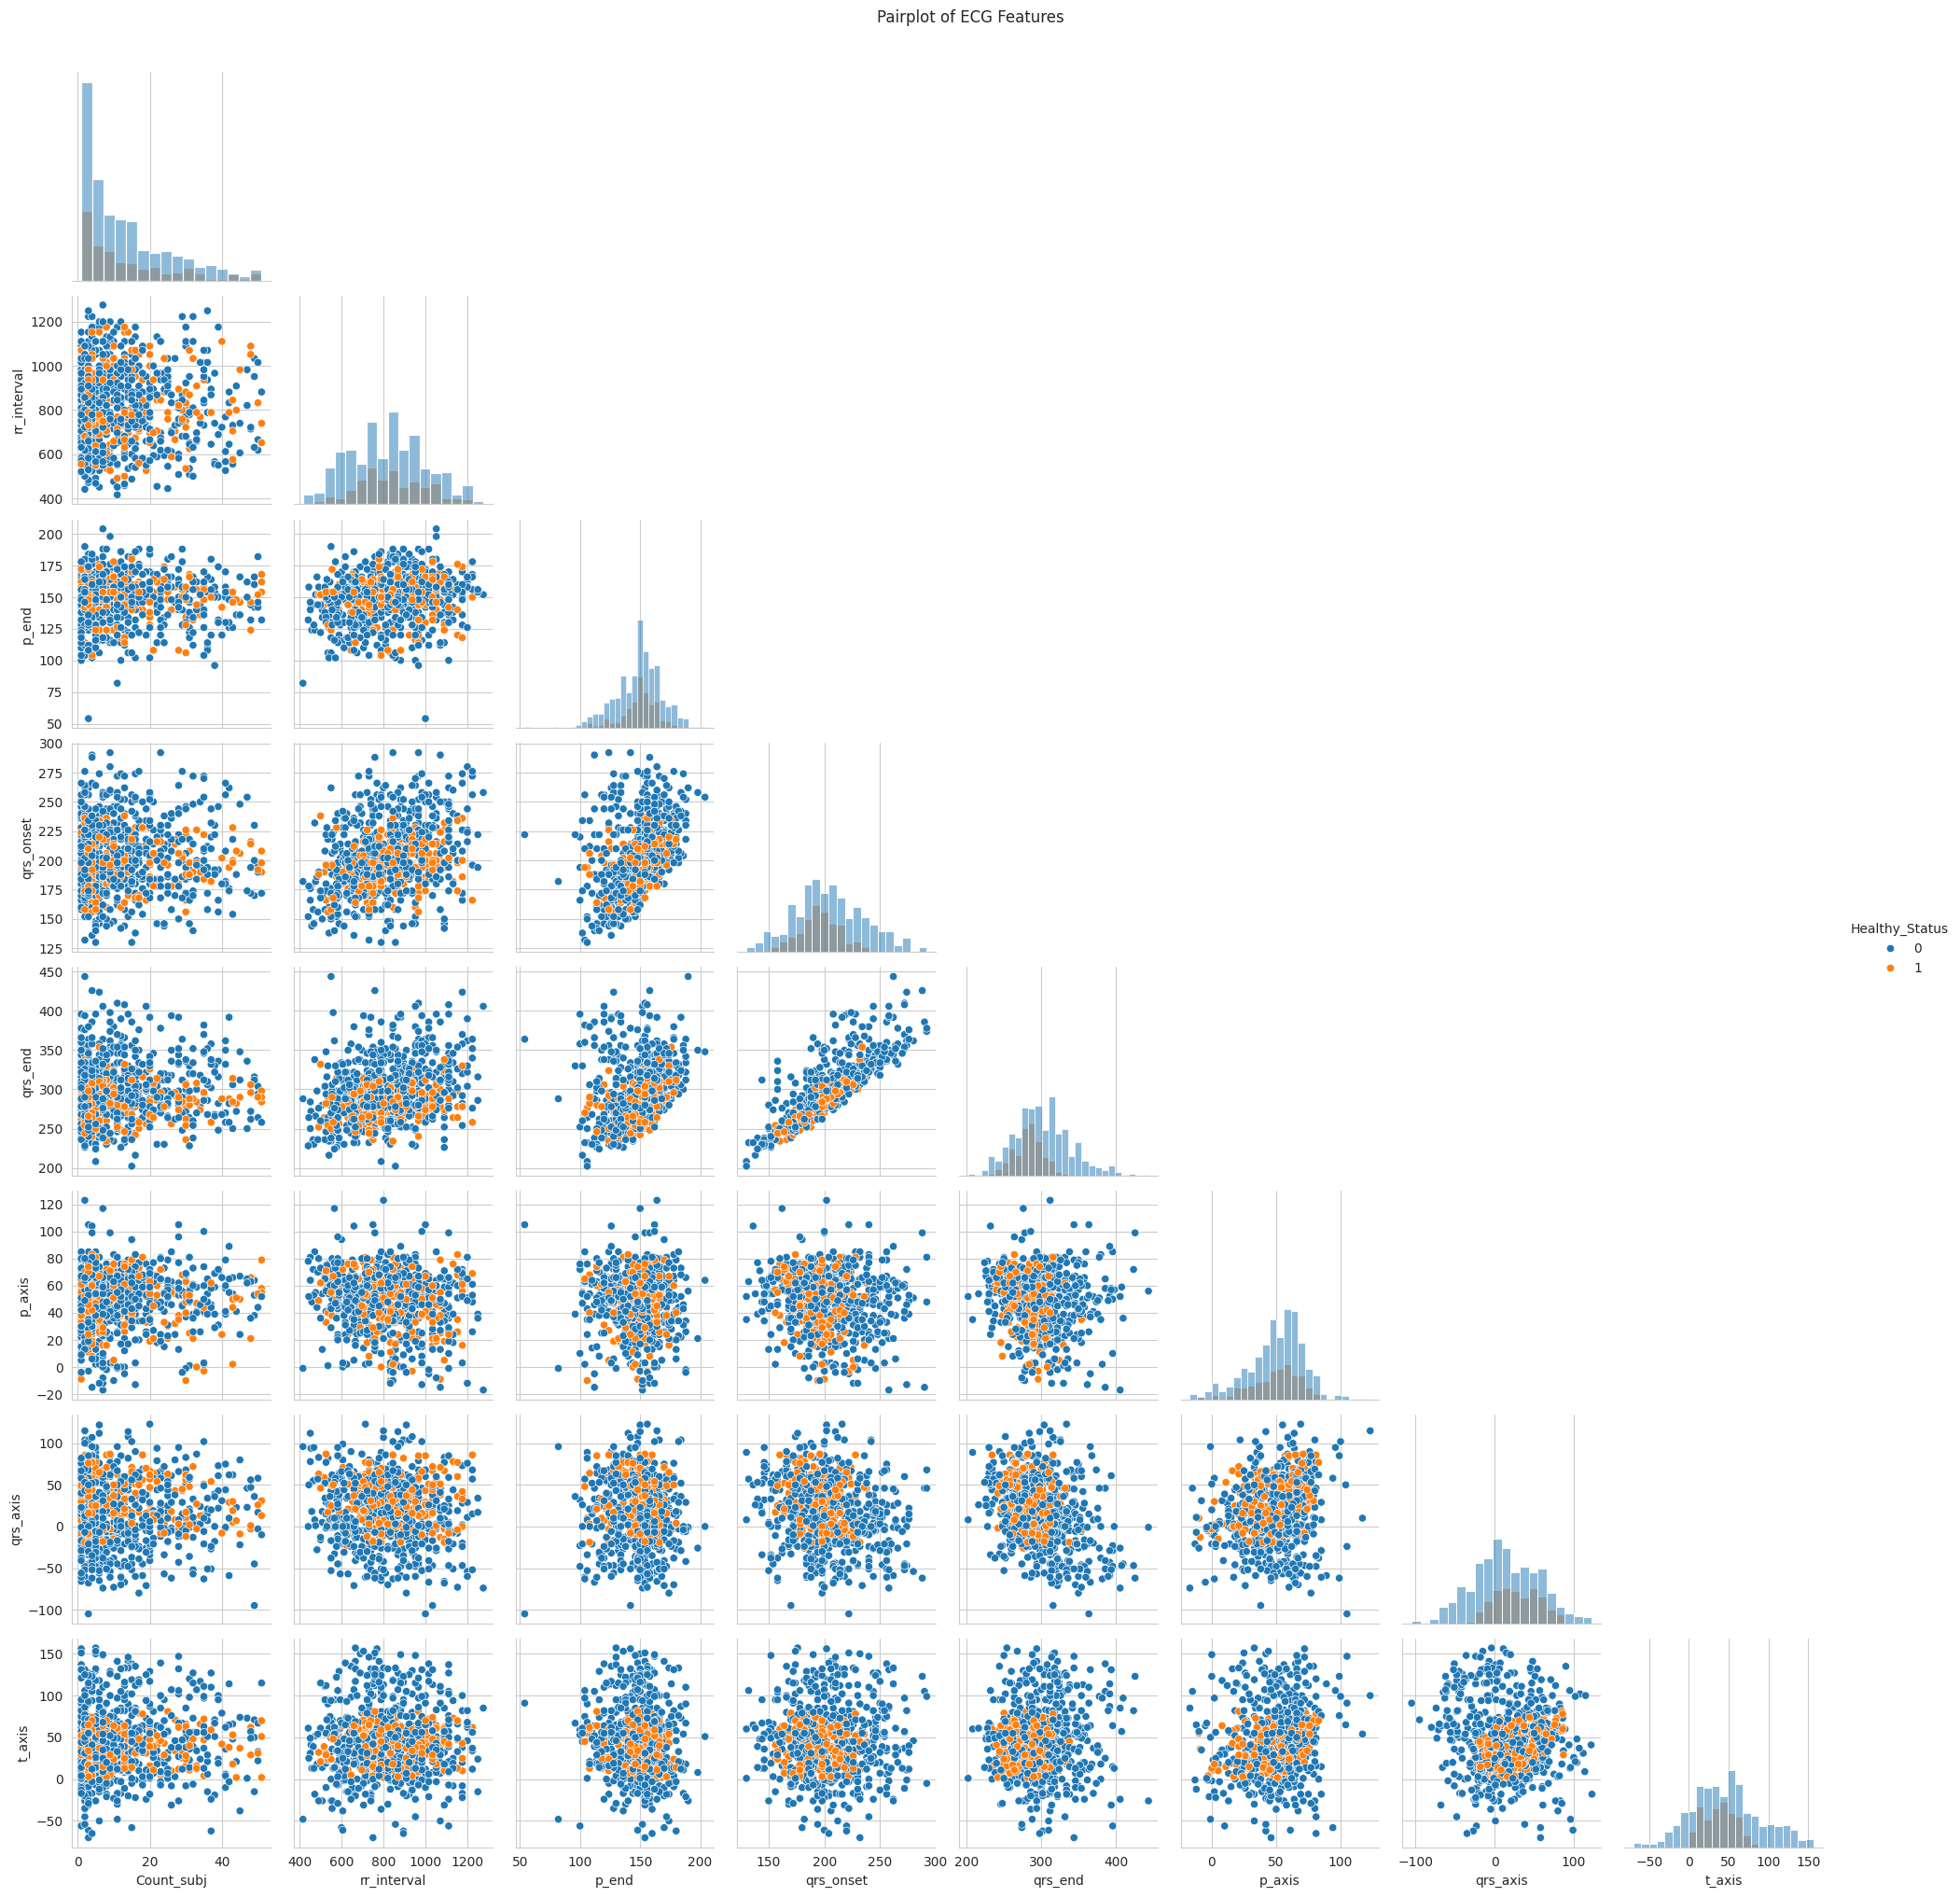

In [15]:
pairplot_sample = clean_df.sample(min(800, len(clean_df)), random_state=42)

pair = sns.pairplot(
    pairplot_sample,
    vars=feature_cols,
    hue="Healthy_Status",
    diag_kind="hist",
    corner=True
)
pair.fig.suptitle("Pairplot of ECG Features", y=1.02)
pair.savefig("/kaggle/working/pairplot_ecg.png", dpi=300)
plt.show()

Для визуального сравнения распределений признаков и попарных зависимостей строится `pairplot`. Для ускорения работы используется случайная подвыборка. Цветовая маркировка отражает принадлежность к классам `Healthy_Status`.

In [17]:
X = clean_df[feature_cols]
y = clean_df["Healthy_Status"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\ny_train distribution:")
print(y_train.value_counts(normalize=True))
print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (2352, 8)
X_test : (589, 8)

y_train distribution:
Healthy_Status
0    0.704082
1    0.295918
Name: proportion, dtype: float64

y_test distribution:
Healthy_Status
0    0.704584
1    0.295416
Name: proportion, dtype: float64


Данные разделены на обучающую и тестовую выборки в соотношении 80/20. Использование параметра `stratify=y` позволяет сохранить исходное соотношение классов в обеих выборках.

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.fit_transform(X)

print("Scaling done.")

Scaling done.


На данном этапе выполняется стандартизация признаков. Это необходимо для корректной работы методов уменьшения размерности и классификации, поскольку признаки имеют разные масштабы.

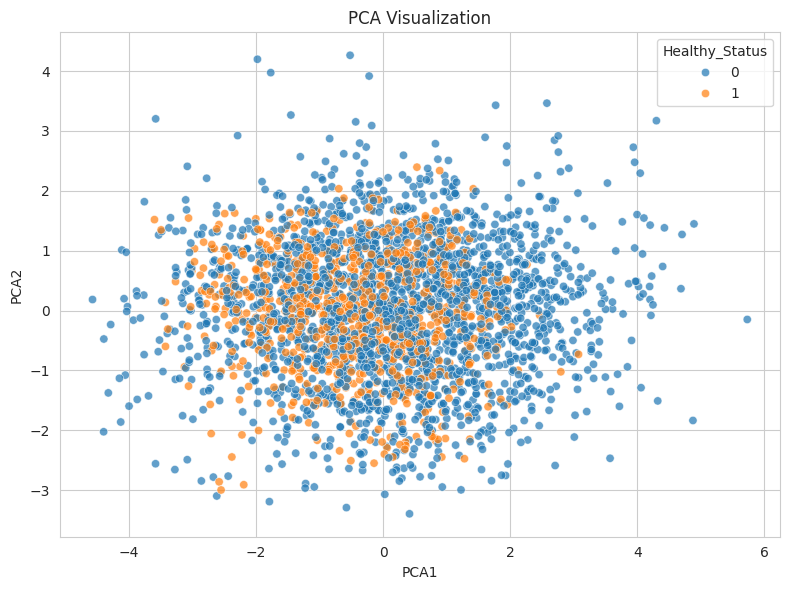

Explained variance ratio: [0.30404762 0.15104893]
Total explained variance: 0.45509654452810866


In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
pca_df["Healthy_Status"] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Healthy_Status",
    alpha=0.7
)
plt.title("PCA Visualization")
plt.tight_layout()
plt.savefig("/kaggle/working/pca_visualization.png", dpi=300)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Метод главных компонент PCA используется для снижения размерности исходных данных до двух компонент с целью визуального анализа структуры выборки и возможной разделимости классов.

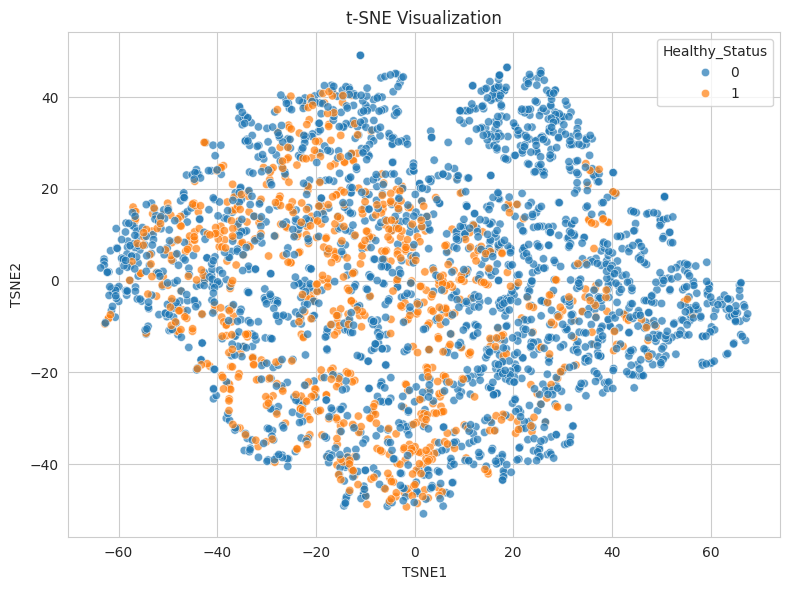

In [20]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_all_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
tsne_df["Healthy_Status"] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Healthy_Status",
    alpha=0.7
)
plt.title("t-SNE Visualization")
plt.tight_layout()
plt.savefig("/kaggle/working/tsne_visualization.png", dpi=300)
plt.show()

Метод t-SNE применяется для нелинейного отображения многомерных данных в двумерное пространство. Он позволяет более наглядно оценить локальную структуру данных и возможное разделение классов.

In [21]:
automl = AutoML()

automl_settings = {
    "time_budget": 180,
    "metric": "f1",
    "task": "classification",
    "log_file_name": "flaml_ecg.log",
    "seed": 42,
    "eval_method": "cv",
    "n_splits": 5,
    "estimator_list": ["lrl1", "lrl2", "rf", "extra_tree"]
}

automl.fit(
    X_train=X_train_scaled,
    y_train=y_train,
    **automl_settings
)

print("Best estimator:", automl.best_estimator)
print("Best config:", automl.best_config)
print("Best validation loss:", automl.best_loss)

[flaml.automl.logger: 03-21 09:46:03] {2375} INFO - task = classification
[flaml.automl.logger: 03-21 09:46:03] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 03-21 09:46:03] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 03-21 09:46:03] {2606} INFO - List of ML learners in AutoML Run: ['lrl1', 'lrl2', 'rf', 'extra_tree']
[flaml.automl.logger: 03-21 09:46:03] {2911} INFO - iteration 0, current learner lrl1
[flaml.automl.logger: 03-21 09:46:03] {3046} INFO - Estimated sufficient time budget=1124s. Estimated necessary time budget=1s.
[flaml.automl.logger: 03-21 09:46:03] {3097} INFO -  at 0.1s,	estimator lrl1's best error=6.2717e-01,	best estimator lrl1's best error=6.2717e-01
[flaml.automl.logger: 03-21 09:46:03] {2911} INFO - iteration 1, current learner extra_tree
[flaml.automl.logger: 03-21 09:46:03] {3097} INFO -  at 0.3s,	estimator extra_tree's best error=1.0000e+00,	best estimator lrl1's best error=6.2717e-01
[flaml.automl.logger: 03-21 09:46:03] {291

Для решения задачи бинарной классификации используется AutoML-фреймворк FLAML. Поиск лучшей модели осуществляется автоматически на основе F1-метрики, которая особенно важна при возможном дисбалансе классов.

In [22]:
y_pred = automl.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc, 4))
print("F1-score:", round(f1, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.747
F1-score: 0.6228

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81       415
           1       0.56      0.71      0.62       174

    accuracy                           0.75       589
   macro avg       0.71      0.74      0.72       589
weighted avg       0.77      0.75      0.75       589



После обучения лучшая модель применяется к тестовой выборке. Рассчитываются основные показатели качества, включая Accuracy и F1-score. Основной метрикой в данной работе является F1-score.

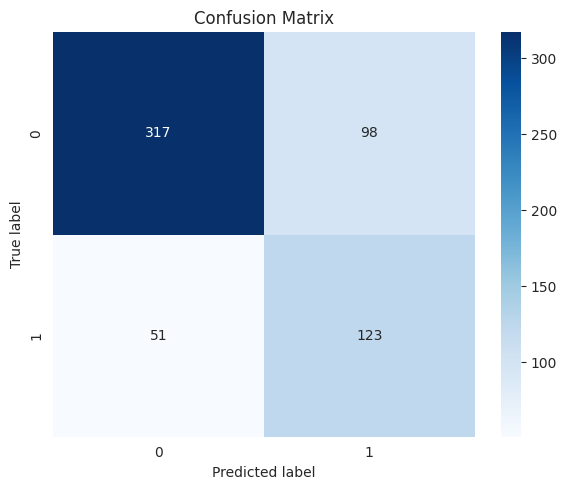

[[317  98]
 [ 51 123]]


In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=300)
plt.show()

print(cm)

Матрица ошибок позволяет детально оценить результаты бинарной классификации, показать количество верных и ошибочных предсказаний и визуально представить структуру ошибок модели.

In [24]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1-score", "Best estimator"],
    "Value": [acc, f1, automl.best_estimator]
})

metrics_df.to_csv("/kaggle/working/ecg_metrics.csv", index=False)
metrics_df

,Metric,Value
0,Accuracy,0.747029
1,F1-score,0.622785
2,Best estimator,rf


Основные результаты эксперимента сохраняются в отдельную таблицу

In [25]:
clean_df.to_csv("/kaggle/working/ecg_cleaned_5000.csv", index=False)

print("Saved files in /kaggle/working/:")
for f in sorted(os.listdir("/kaggle/working")):
    print(f)

Saved files in /kaggle/working/:
.virtual_documents
boxplot_after_cleaning.png
boxplot_before_cleaning.png
confusion_matrix.png
correlation_heatmap.png
ecg_cleaned_5000.csv
ecg_metrics.csv
flaml_ecg.log
pairplot_ecg.png
pca_visualization.png
tsne_visualization.png


На завершающем этапе сохраняются очищенный датасет, изображения графиков и таблица с метриками.